In [1]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = Path("/home/jonas/Datasets/TikZ/train-big")
MANIFEST_PATH = DATASET_PATH / "hardest_manifest.csv"

df = pd.read_csv(MANIFEST_PATH)

df.head()

,code_path,image_path,vlm_description_path,reference_image,reference_code,input_image_format_for_vlm,vlm_description,sft_loss,sft_answer_tokens
0,/data/references/datikz_v4_00232638.txt,/data/images/datikz_v4_00232638.png,/data/vlm_descriptions/datikz_v4_00232638.txt,/images/datikz_v4_00232638.png,/references/datikz_v4_00232638.txt,file:///images/datikz_v4_00232638.png,file:///vlm_descriptions/datikz_v4_00232638.txt,5.953898,473
1,/data/references/our_dataset_00001966.txt,/data/images/our_dataset_00001966.png,/data/vlm_descriptions/our_dataset_00001966.txt,/images/our_dataset_00001966.png,/references/our_dataset_00001966.txt,file:///images/our_dataset_00001966.png,file:///vlm_descriptions/our_dataset_00001966.txt,5.260902,115
2,/data/references/geotikz_bridge_base_00105692.txt,/data/images/geotikz_bridge_base_00105692.png,/data/vlm_descriptions/geotikz_bridge_base_001...,/images/geotikz_bridge_base_00105692.png,/references/geotikz_bridge_base_00105692.txt,file:///images/geotikz_bridge_base_00105692.png,file:///vlm_descriptions/geotikz_bridge_base_0...,4.513975,311
3,/data/references/datikz_v4_00315275.txt,/data/images/datikz_v4_00315275.png,/data/vlm_descriptions/datikz_v4_00315275.txt,/images/datikz_v4_00315275.png,/references/datikz_v4_00315275.txt,file:///images/datikz_v4_00315275.png,file:///vlm_descriptions/datikz_v4_00315275.txt,4.173953,367
4,/data/references/datikz_v4_00015757.txt,/data/images/datikz_v4_00015757.png,/data/vlm_descriptions/datikz_v4_00015757.txt,/images/datikz_v4_00015757.png,/references/datikz_v4_00015757.txt,file:///images/datikz_v4_00015757.png,file:///vlm_descriptions/datikz_v4_00015757.txt,4.153597,665


In [2]:
df_sorted = df.sort_values("sft_loss", ascending=False).reset_index(drop=True)
df_sorted[["image_path", "sft_loss", "sft_answer_tokens"]].head(20)

,image_path,sft_loss,sft_answer_tokens
0,/data/images/datikz_v4_00232638.png,5.953898,473
1,/data/images/our_dataset_00001966.png,5.260902,115
2,/data/images/geotikz_bridge_base_00105692.png,4.513975,311
3,/data/images/datikz_v4_00315275.png,4.173953,367
4,/data/images/datikz_v4_00015757.png,4.153597,665
5,/data/images/our_dataset_00058617.png,4.141926,807
6,/data/images/datikz_v4_00305730.png,4.140755,193
7,/data/images/datikz_v4_00237229.png,4.121300,156
8,/data/images/datikz_v4_00117592.png,4.069176,204
9,/data/images/datikz_v4_00333954.png,4.029028,139


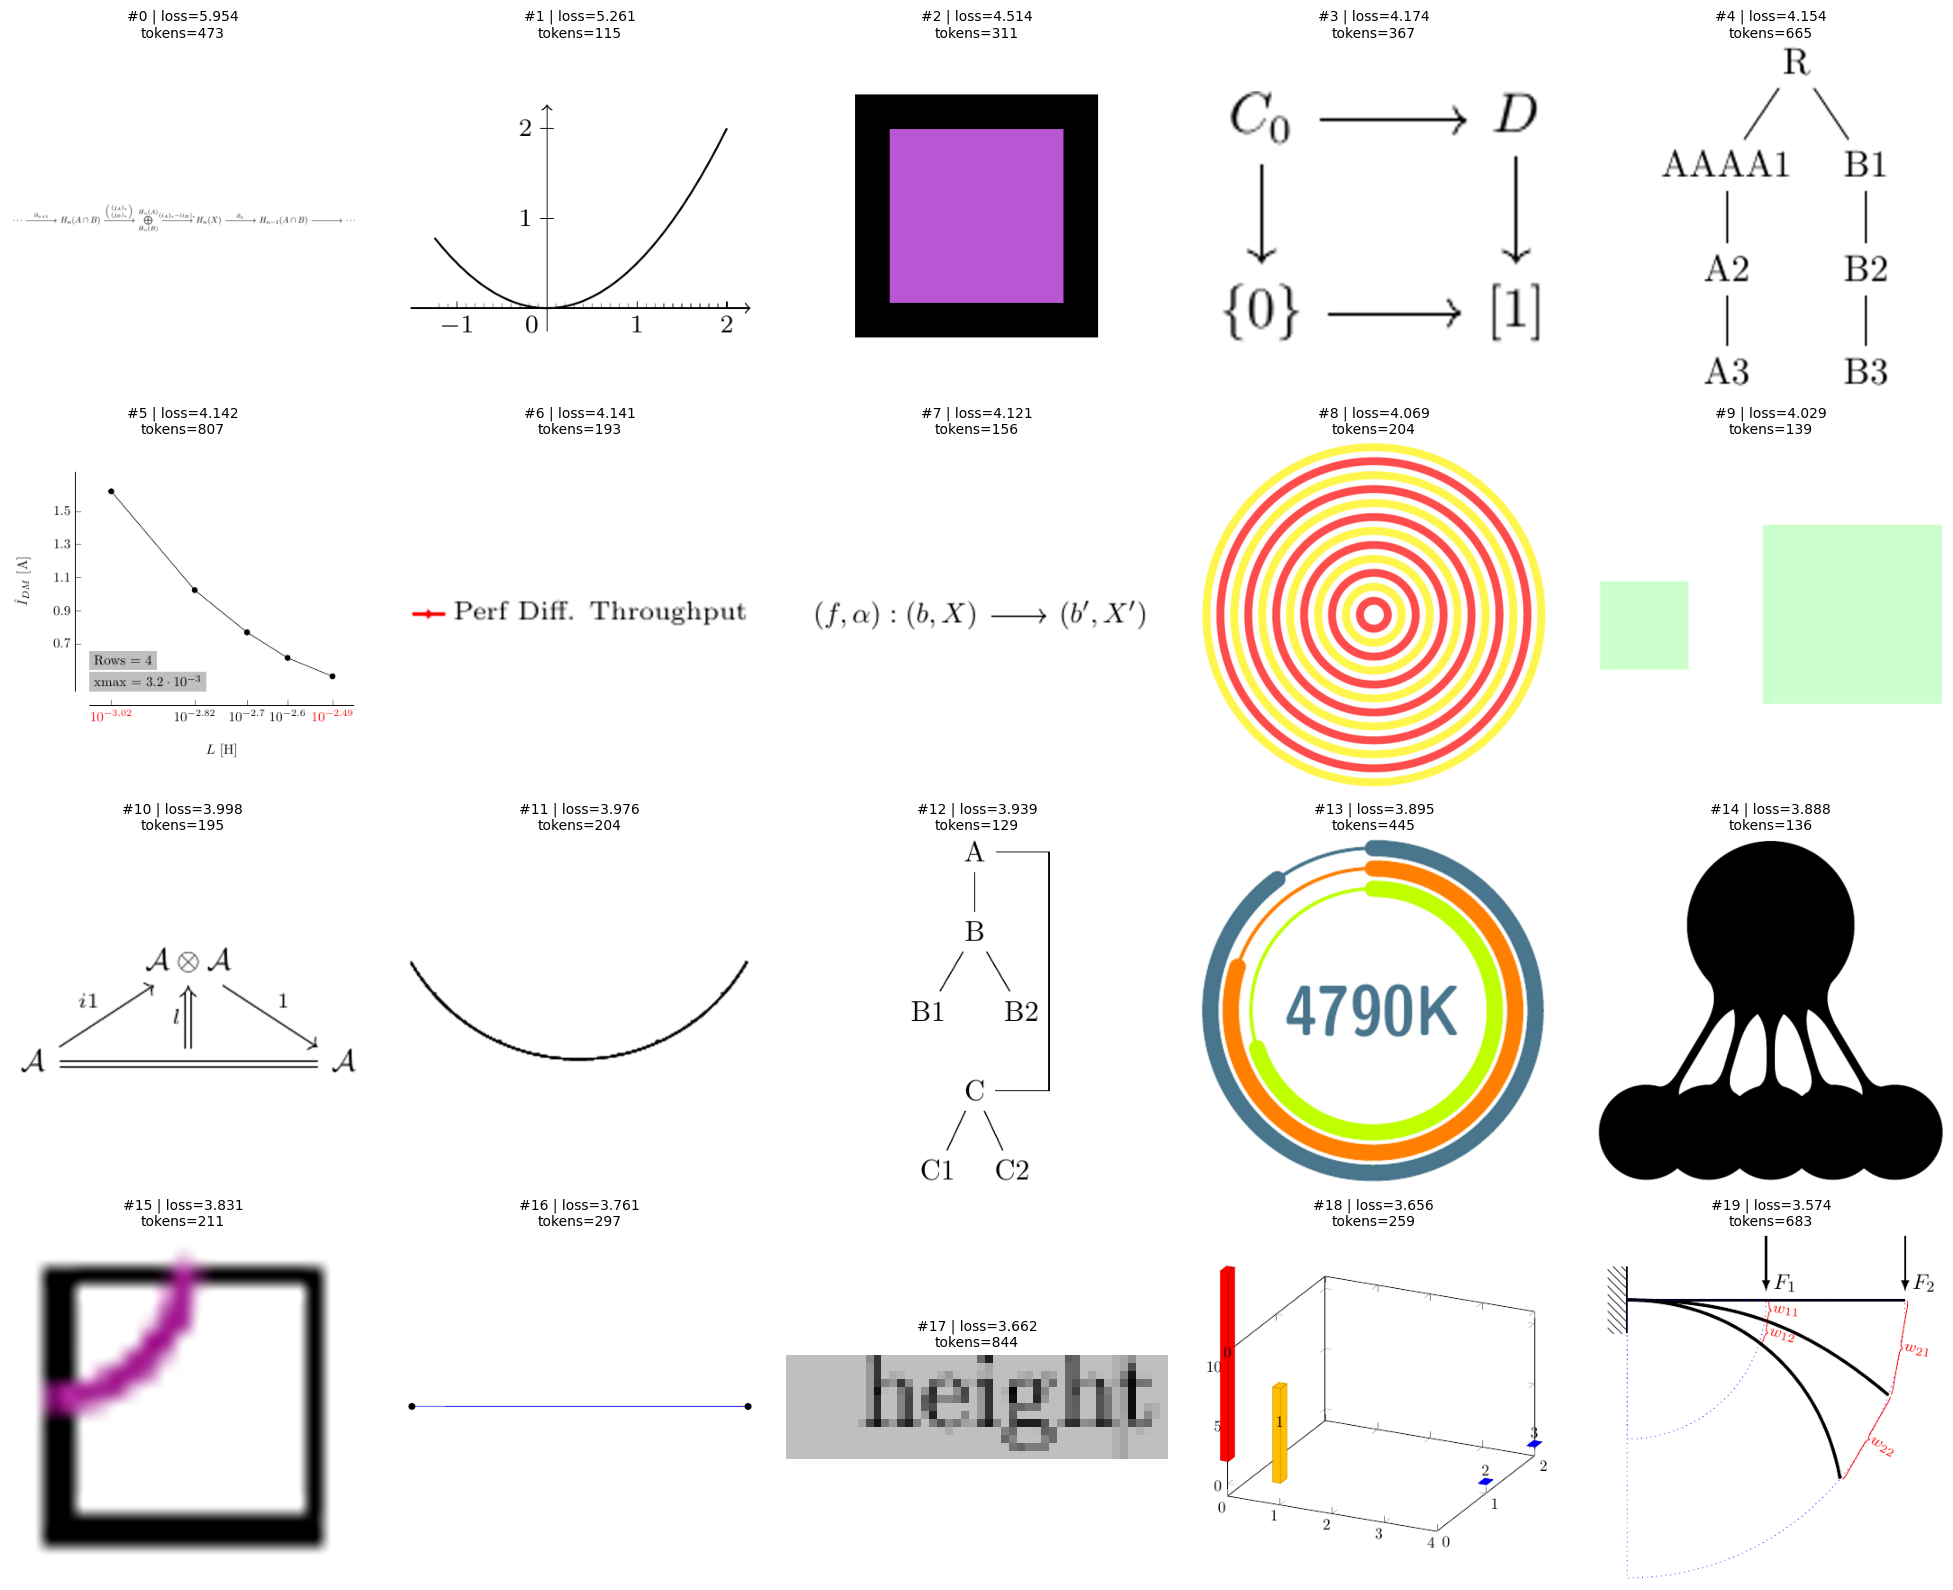

In [4]:
def resolve(root, p):
    p = p.replace("/data", str(DATASET_PATH))
    p = Path(str(p))
    return p if p.is_absolute() else root / p


def show_samples(df, n=12, cols=4, root=DATASET_PATH):
    rows = min(n, len(df))
    plot_rows = (rows + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * plot_rows))

    for i in range(rows):
        row = df.iloc[i]
        img_path = resolve(root, row["image_path"])
        img = Image.open(img_path).convert("RGB")

        ax = plt.subplot(plot_rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        loss = row["sft_loss"]
        tokens = row.get("sft_answer_tokens", None)

        title = f"#{i} | loss={loss:.3f}"
        if tokens is not None:
            title += f"\ntokens={int(tokens)}"

        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


show_samples(df_sorted, n=20, cols=5)

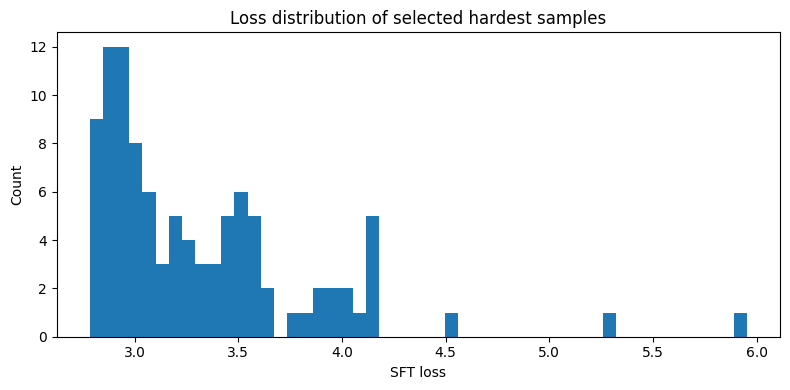

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(df["sft_loss"], bins=50)
plt.xlabel("SFT loss")
plt.ylabel("Count")
plt.title("Loss distribution of selected hardest samples")
plt.tight_layout()
plt.show()